<div style="display: flex; align-items: center;">
    <img alt="udeA logo" height="140px" src="https://github.com/freddyduitama/images/blob/master/logo.png?raw=true" style="width:107px;height:152px; margin-right: 40px;">
    <div style="text-align: center;">
        <h1><b><font color='0B5345'>Sistema Predictor de grupos relacionados por el diagnóstico</font></b></h1>
        <h1><b><font color='0B5345'>Modelo Baseline</font></b></h1>
        <h2><font color='0B5345'>Luisa Enciso - María Ostos - Santiago Rivera</font></h2>
    </div>
</div>


In [1]:
import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler


In [2]:
def mostrar_informe(df):
    print("Informe estadístico de la base de datos")
    print("="*50, "\n")

    # 1. Información general
    print(f"Número de registros: {df.shape[0]}")
    print(f"Número de columnas: {df.shape[1]}\n")

    # 2. Valores nulos por columna
    print("Valores nulos por columna:")
    print(df.isna().sum())
    print("\n")

    # 3. Valores únicos por columna
    print("Número de valores únicos por columna:")
    print(df.nunique())
    print("\n")

    # 4. Estadísticas descriptivas para columnas numéricas
    print("Estadísticas descriptivas (numéricas):")
    print(df.describe())
    print("\n")

    # 5. Frecuencias para variables categóricas
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("Frecuencias para variables categóricas:")
        for col in cat_cols:
            print(f"\nColumna: {col}")
            print(df[col].value_counts(dropna=False))
    else:
        print("No se encontraron columnas categóricas.")

<hr>

# **Inspección de la base de datos**

In [3]:
# Ruta del archivo Excel
archivo_excel = 'DataBase.xlsx'
# Cargar el archivo Excel
df = pd.read_excel(archivo_excel, engine='openpyxl')
# Mostrar las primeras filas
df.head()

,Num caso,Aseguradora -Código-,Aseguradora -Descripción-,Edad,Grupo Edad,Sexo,Codigo de ciudad,Fecha de ingreso,Tipo de ingreso,Fecha de egreso,...,Proc28,Proc29,Proc30,Tipo servicio,Causa Basica de muerte,Infecciones,Infección Quirurgica,GRD -Código,GRD -Descripción,Tipo GRD
0,413799.0,204,Aseguradora_29,38,35-39,F,5001,30052005,URGENCIA,19062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,14143,MH ACCIDENTE VASCULAR CEREBRAL CON INFARTO w/MCC,M
1,412359.0,313,Aseguradora_56,27,25-29,M,5088,11032005,URGENCIA,10042005,...,NaN,NaN,NaN,NO APLICA,NaN,NO,NO,184153,MH INFECCIÓN POR VIRUS DE INMUNODEFICIENCIA HU...,M
2,412552.0,313,Aseguradora_56,39,35-39,M,5001,20032005,URGENCIA,10042005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCIÓN POR VIRUS DE INMUNODEFICIENCIA HU...,M
3,414131.0,227,Aseguradora_46,24,20-24,M,5001,20062005,URGENCIA,22062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCIÓN POR VIRUS DE INMUNODEFICIENCIA HU...,M
4,410573.0,227,Aseguradora_46,60,60-64,M,5001,24112004,URGENCIA,7012005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184112,MH INFECCIONES POST OPERATORIAS Y POSTRAUMÁTIC...,M


## **Informe Estadístico Inicial de la Base de Datos**

In [4]:
df_informe = pd.read_excel(archivo_excel, engine='openpyxl')
mostrar_informe(df_informe)

Informe estadístico de la base de datos

Número de registros: 27869
Número de columnas: 68

Valores nulos por columna:
Num caso                     1
Aseguradora -Código-         0
Aseguradora -Descripción-    0
Edad                         0
Grupo Edad                   0
                            ..
Infecciones                  0
Infección Quirurgica         0
GRD -Código                  0
GRD -Descripción             0
Tipo GRD                     0
Length: 68, dtype: int64


Número de valores únicos por columna:
Num caso                     7900
Aseguradora -Código-           62
Aseguradora -Descripción-      71
Edad                          108
Grupo Edad                     20
                             ... 
Infecciones                     4
Infección Quirurgica            4
GRD -Código                   608
GRD -Descripción              608
Tipo GRD                        4
Length: 68, dtype: int64


Estadísticas descriptivas (numéricas):
            Num caso  Aseguradora -

## 1. Descripción General

- **Número total de registros:** 27,869
- **Número total de columnas:** 68

Este informe presenta un análisis descriptivo preliminar con el fin de entender la estructura, calidad y características generales del conjunto de datos.



## 2. Calidad de los Datos

- **Valores nulos por columna:**
    
    La mayoría de las columnas no presentan valores nulos. Se identifica 1 registro con valor nulo en la columna `Num caso`.
      



## 3. Distribución de Datos Categóricos

Se presentan las frecuencias de las principales variables categóricas para identificar posibles valores atípicos o inconsistencias, además de observar la distribución general:

- **Sexo:**
    - Masculino (M): 14,353
    - Femenino (F): 13,512
    - Valores inconsistentes (m, f): 4 (corregir para homogeneizar)
- **Tipo de ingreso:**
    - Urgencia: 25,570
    - Programado: 2,294
    - Valores inconsistentes (variaciones en mayúsculas/minúsculas): corregir para uniformidad
- **Cuidados intensivos:**
    - NO: 26,681
    - SI: 1,182
    - Valores inconsistentes (variaciones en mayúsculas/minúsculas): corregir
- **Grupo Etario:**
    
    Distribución detallada por rangos de edad, destacando grupos mayores (75-79, 80-84 años) con mayor frecuencia.
    
- **Aseguradora:**
    
    71 categorías, con 5 aseguradoras predominantes que concentran la mayoría de los registros.
    
- **Diagnósticos (Dx principal y Dxr 1-9):**
    
    Amplia variedad con valores NaN significativos en las últimas columnas de diagnósticos secundarios.
    


## 4. Estadísticas Descriptivas para Variables Numéricas

- **Edad:**
    - Media: 57.7 años
    - Rango: 0 a 109 años
    - Desviación estándar: 24.17
- **Días de estancia hospitalaria:**
    - Media: 8.45 días
    - Rango: 0 a 174 días
    - Mediana: 6 días
- **Días en Unidad de Cuidados Intensivos:**
    - Media: 0.38 días
    - Alta dispersión con máximo de 92 días, pero la mayoría sin estancia en UCI.
    
- **Variables de Procedimientos (Proc22 a Proc30):**
    
    Presentan muchos valores faltantes (solo disponibles en pocas observaciones), con medias alrededor de 83-89 y alta variabilidad en algunos casos. Se debe evaluar relevancia para análisis futuros.
    



## 5. Observaciones Generales
- Unificar formatos en variables categóricas (ej. mayúsculas/minúsculas).
- Tratar valores faltantes, en particular en columnas diagnósticas y procedimientos.
- Validar posibles registros duplicados.
- Eliminar categorías muy específicas o poco frecuentes en variables categóricas para evitar ruido.



## 6. Conclusiones preliminares

El dataset es amplio y contiene información clínica valiosa. Se evidencia buena calidad general en términos de datos faltantes, salvo excepciones puntuales. La distribución etaria y los diagnósticos principales presentan un perfil coherente para un estudio de análisis de gestión hospitalaria. Sin embargo, es imprescindible realizar un proceso de limpieza y transformación para garantizar la calidad y precisión en análisis posteriores.

<hr>

# **Limpieza de la base de datos**

In [5]:
# ====================================================================
# 1. LIMPIEZA BÁSICA DE TEXTO
# ====================================================================
# Se estandarizan los textos a mayúsculas y se eliminan las tildes,
# aplicando esta limpieza únicamente a las columnas de tipo string
# (sin afectar columnas numéricas). Además, se normalizan los nombres
# de las columnas.
# ====================================================================

def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = texto.upper()
        texto = unicodedata.normalize('NFKD', texto)
        texto = ''.join([c for c in texto if not unicodedata.combining(c)])
        return texto
    return texto

# Aplicar solo a columnas de texto
columnas_texto = df.select_dtypes(include='object').columns
df[columnas_texto] = df[columnas_texto].applymap(limpiar_texto)

# Limpiar nombres de columnas
df.columns = [limpiar_texto(col) for col in df.columns]

df.head()


C:\Users\luisa\AppData\Local\Temp\ipykernel_21964\3508867996.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[columnas_texto] = df[columnas_texto].applymap(limpiar_texto)


,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,PROC28,PROC29,PROC30,TIPO SERVICIO,CAUSA BASICA DE MUERTE,INFECCIONES,INFECCION QUIRURGICA,GRD -CODIGO,GRD -DESCRIPCION,TIPO GRD
0,413799.0,204,ASEGURADORA_29,38,35-39,F,5001,30052005,URGENCIA,19062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,14143,MH ACCIDENTE VASCULAR CEREBRAL CON INFARTO W/MCC,M
1,412359.0,313,ASEGURADORA_56,27,25-29,M,5088,11032005,URGENCIA,10042005,...,NaN,NaN,NaN,NO APLICA,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
2,412552.0,313,ASEGURADORA_56,39,35-39,M,5001,20032005,URGENCIA,10042005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
3,414131.0,227,ASEGURADORA_46,24,20-24,M,5001,20062005,URGENCIA,22062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
4,410573.0,227,ASEGURADORA_46,60,60-64,M,5001,24112004,URGENCIA,7012005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184112,MH INFECCIONES POST OPERATORIAS Y POSTRAUMATIC...,M


In [6]:
# =============================================================================
# 2. NORMALIZACIÓN DE VALORES EQUIVALENTES
# =============================================================================
# Se unifican valores semánticamente equivalentes que presentan
# diferencias en su escritura. Ejemplo: "URGENCIAS PEDIATRICAS" → "URGENCIA".
# Esta etapa mejora la consistencia y reduce la cardinalidad de las categorías.
# =============================================================================

normalizaciones = {
    'TIPO DE INGRESO': {
        'URGENCIAS': 'URGENCIA',
        'URGENCIA ADULTOS': 'URGENCIA',
        'U. ADULTOS': 'URGENCIA',
        'URGENCIA PEDIATRICA': 'URGENCIA',
        'URGENCIA OBSTETRICA': 'URGENCIA',
    },
    'SITUACION AL ALTA': {
        'MUERTO': 'FALLECIDO',
        'DEFUNCION': 'FALLECIDO',
    },
    'SERVICIOALTA': {
        'URGENCIAS': 'URGENCIA',
        'U. ADULTOS': 'URGENCIA',
    }
}

for columna, reemplazos in normalizaciones.items():
    if columna in df.columns:
        df[columna] = df[columna].replace(reemplazos)

print("Valores equivalentes normalizados.")
df.head()

Valores equivalentes normalizados.


,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,PROC28,PROC29,PROC30,TIPO SERVICIO,CAUSA BASICA DE MUERTE,INFECCIONES,INFECCION QUIRURGICA,GRD -CODIGO,GRD -DESCRIPCION,TIPO GRD
0,413799.0,204,ASEGURADORA_29,38,35-39,F,5001,30052005,URGENCIA,19062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,14143,MH ACCIDENTE VASCULAR CEREBRAL CON INFARTO W/MCC,M
1,412359.0,313,ASEGURADORA_56,27,25-29,M,5088,11032005,URGENCIA,10042005,...,NaN,NaN,NaN,NO APLICA,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
2,412552.0,313,ASEGURADORA_56,39,35-39,M,5001,20032005,URGENCIA,10042005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
3,414131.0,227,ASEGURADORA_46,24,20-24,M,5001,20062005,URGENCIA,22062005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
4,410573.0,227,ASEGURADORA_46,60,60-64,M,5001,24112004,URGENCIA,7012005,...,NaN,NaN,NaN,URGENCIA ADULTOS,NaN,NO,NO,184112,MH INFECCIONES POST OPERATORIAS Y POSTRAUMATIC...,M


In [7]:
# ==========================================================================
# 3. ELIMINACIÓN DE COLUMNAS PROBLEMÁTICAS
# ==========================================================================
# Se descartan columnas que aportan poco valor al análisis:
# - Columnas con más del 70% de valores nulos
# - Columnas con un único valor distinto (baja variabilidad)
# ==========================================================================

# Columnas con muchos nulos
umbral_nan = 0.7
columnas_a_eliminar = df.columns[df.isna().mean() > umbral_nan].tolist()

# Columnas con un solo valor
columnas_un_valor = [col for col in df.columns if df[col].nunique() == 1]
# Unificar y eliminar
todas_a_eliminar = list(set(columnas_a_eliminar + columnas_un_valor))
df = df.drop(columns=[col for col in todas_a_eliminar if col in df.columns])
print(f"Columnas eliminadas: {todas_a_eliminar}")
df.head()

Columnas eliminadas: ['DXR 9', 'PROC8', 'PROC13', 'PROC15', 'PROC17', 'PROC7', 'PROC25', 'PROC5', 'PROC24', 'PROC21', 'PROC20', 'CAUSA EXTERNA', 'DXR 8', 'DXR 10 ', 'PROC14', 'PROC28', 'PROC10', 'PROC6', 'CAUSA BASICA DE MUERTE', 'PROC26', 'PROC9', 'PROC19', 'PROC29', 'DXR 7', 'PROC12', 'PROC23', 'PROC16', 'PROC22', 'PROC11', 'PROC27', 'CODIGO CAUSA EXTERNA', 'PROC18', 'PROC30', 'PROC4']


,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,GRD -CODIGO,GRD -DESCRIPCION,TIPO GRD
0,413799.0,204,ASEGURADORA_29,38,35-39,F,5001,30052005,URGENCIA,19062005,...,ALTA MEDICA,43.11,54.91,87.44,URGENCIA ADULTOS,NO,NO,14143,MH ACCIDENTE VASCULAR CEREBRAL CON INFARTO W/MCC,M
1,412359.0,313,ASEGURADORA_56,27,25-29,M,5088,11032005,URGENCIA,10042005,...,ALTA MEDICA,87.44,NaN,NaN,NO APLICA,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
2,412552.0,313,ASEGURADORA_56,39,35-39,M,5001,20032005,URGENCIA,10042005,...,ALTA MEDICA,38.93,45.23,87.44,URGENCIA ADULTOS,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
3,414131.0,227,ASEGURADORA_46,24,20-24,M,5001,20062005,URGENCIA,22062005,...,ALTA MEDICA,88.01,NaN,NaN,URGENCIA ADULTOS,NO,NO,184153,MH INFECCION POR VIRUS DE INMUNODEFICIENCIA HU...,M
4,410573.0,227,ASEGURADORA_46,60,60-64,M,5001,24112004,URGENCIA,7012005,...,ALTA MEDICA,45.16,87.44,88.79,URGENCIA ADULTOS,NO,NO,184112,MH INFECCIONES POST OPERATORIAS Y POSTRAUMATIC...,M


In [8]:
# ================================================================
# 4. CODIFICACIÓN DE VARIABLES
# ================================================================
# - Variables binarias: codificar con 0 y 1.
# - Variables categóricas frecuentes: codificar por frecuencia.
# ================================================================

from sklearn.preprocessing import MinMaxScaler

# 1. Identificar variables categóricas
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns

# 2. Codificación
for col in columnas_categoricas:
    valores_unicos = df[col].dropna().unique()
    if len(valores_unicos) == 2:
        # Codificación binaria
        df[col] = df[col].map({valores_unicos[0]: 0, valores_unicos[1]: 1})
    else:
        # Codificación por frecuencia
        frecuencia = df[col].value_counts()
        df[col] = df[col].map(frecuencia)

# Mostrar primeras filas para ver resultado
df.head()


,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,GRD -CODIGO,GRD -DESCRIPCION,TIPO GRD
0,413799.0,204,759,38,942,0,5001,30052005,0,19062005,...,0.0,43.11,54.91,87.44,24836.0,0,0,14143,54,0
1,412359.0,313,5080,27,1047,1,5088,11032005,0,10042005,...,0.0,87.44,NaN,NaN,2349.0,0,0,184153,59,0
2,412552.0,313,5080,39,942,1,5001,20032005,0,10042005,...,0.0,38.93,45.23,87.44,24836.0,0,0,184153,59,0
3,414131.0,227,13322,24,1073,1,5001,20062005,0,22062005,...,0.0,88.01,NaN,NaN,24836.0,0,0,184153,59,0
4,410573.0,227,13322,60,2195,1,5001,24112004,0,7012005,...,0.0,45.16,87.44,88.79,24836.0,0,0,184112,55,0


In [9]:
# ================================================================
# 5. NORMALIZACIÓN MIN-MAX
# ================================================================
# - Se imputan NaN con 0
# - Se suma un pequeño epsilon para evitar ceros exactos
# - Se aplica MinMaxScaler para escalar al rango [0, 1]
# - Se guarda scaler y columnas usadas
# - Se reconstruye el DataFrame final
# ================================================================

import pandas as pd
import numpy as np
import joblib
import pickle
from sklearn.preprocessing import MinMaxScaler

# 1. Limpiar nombres columnas (quita espacios a izquierda y derecha)
df.columns = df.columns.str.strip()

# 2. Rellenar NaN con 0
df_clean = df.fillna(0)

# 3. Definir columnas objetivo (etiquetas) exactas
columnas_no_escalar = ['GRD -CODIGO', 'GRD -DESCRIPCION']

# 4. Crear lista de columnas para el modelo excluyendo etiquetas
columnas_modelo = [col for col in df_clean.columns if col not in columnas_no_escalar]

print("Columnas para escalar y usar en modelo:")
print(columnas_modelo)

# 5. Añadir epsilon solo a columnas numéricas para evitar ceros exactos
epsilon = 1e-3
df_adjusted = df_clean.copy()

for col in columnas_modelo:
    if pd.api.types.is_numeric_dtype(df_adjusted[col]):
        df_adjusted[col] += epsilon

# 6. Ajustar y transformar con scaler SOLO columnas de entrada
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_adjusted[columnas_modelo])

# 7. Guardar scaler y columnas_modelo ordenadas
joblib.dump(scaler, 'scaler_modelo.pkl')

# Asegúrate de guardar columnas_modelo como lista ordenada
with open('columnas_modelo.pkl', 'wb') as f:
    pickle.dump(columnas_modelo, f)

# 8. Crear DataFrame escalado con columnas en orden original (no ordenado)
df_scaled = pd.DataFrame(scaled_values, columns=columnas_modelo)

# 9. Agregar columnas objetivo sin escalar
for col in columnas_no_escalar:
    df_scaled[col] = df_adjusted[col]

print("Normalización Min-Max aplicada correctamente.")
df_scaled.head()

Columnas para escalar y usar en modelo:
['NUM CASO', 'ASEGURADORA -CODIGO-', 'ASEGURADORA -DESCRIPCION-', 'EDAD', 'GRUPO EDAD', 'SEXO', 'CODIGO DE CIUDAD', 'FECHA DE INGRESO', 'TIPO DE INGRESO', 'FECHA DE EGRESO', 'DIAS ESTANCIA', 'SERVICIOALTA', 'CUIDADOS INTENSIVOS', 'DIAS DE UNIDAD CUIDADO INTENSIVO', 'DX DE INGRESO', 'DX PRINCIPAL DE EGRESO', 'DX PRINCIPAL DE EGRESO .1', 'DX PPAL 3 CARACTERES', 'DXR 1', 'DXR 2', 'DXR 3', 'DXR 4', 'DXR 5', 'DXR-6', 'SITUACION AL ALTA', 'PROC1', 'PROC2', 'PROC3', 'TIPO SERVICIO', 'INFECCIONES', 'INFECCION QUIRURGICA', 'TIPO GRD']
Normalización Min-Max aplicada correctamente.


,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,TIPO GRD,GRD -CODIGO,GRD -DESCRIPCION
0,0.997570,0.626543,0.056903,0.348624,0.336940,0.0,0.000000,0.964464,0.0,0.599469,...,0.0,0.432744,0.559165,0.893887,1.00000,0.0,0.0,0.0,14143,54
1,0.994098,0.962963,0.381278,0.247706,0.376119,1.0,0.001041,0.332780,0.0,0.299900,...,0.0,0.877735,0.000000,0.000000,0.09458,0.0,0.0,0.0,184153,59
2,0.994564,0.962963,0.381278,0.357798,0.336940,1.0,0.000000,0.631684,0.0,0.299900,...,0.0,0.390785,0.460591,0.893887,1.00000,0.0,0.0,0.0,184153,59
3,0.998370,0.697531,1.000000,0.220183,0.385821,1.0,0.000000,0.632680,0.0,0.699103,...,0.0,0.883457,0.000000,0.000000,1.00000,0.0,0.0,0.0,184153,59
4,0.989793,0.697531,1.000000,0.550459,0.804478,1.0,0.000000,0.767187,0.0,0.199269,...,0.0,0.453323,0.890428,0.907688,1.00000,0.0,0.0,0.0,184112,55


In [10]:
import os

BASE_DIR = os.getcwd()    
SCALER_PATH = os.path.join(BASE_DIR, 'scaler_modelo.pkl')
COLUMNAS_PATH = os.path.join(BASE_DIR, 'columnas_modelo.pkl')

scaler2 = joblib.load(SCALER_PATH)
columnas = joblib.load(COLUMNAS_PATH)


print(f"Número columnas escaladas: {scaler2.n_features_in_}")
print(f"Columnas escaladas: {scaler2.feature_names_in_}")
print(f"Número columnas : {len(columnas)}")
print(f"Columnas modelo: {columnas}")

Número columnas escaladas: 32
Columnas escaladas: ['NUM CASO' 'ASEGURADORA -CODIGO-' 'ASEGURADORA -DESCRIPCION-' 'EDAD'
 'GRUPO EDAD' 'SEXO' 'CODIGO DE CIUDAD' 'FECHA DE INGRESO'
 'TIPO DE INGRESO' 'FECHA DE EGRESO' 'DIAS ESTANCIA' 'SERVICIOALTA'
 'CUIDADOS INTENSIVOS' 'DIAS DE UNIDAD CUIDADO INTENSIVO' 'DX DE INGRESO'
 'DX PRINCIPAL DE EGRESO' 'DX PRINCIPAL DE EGRESO .1'
 'DX PPAL 3 CARACTERES' 'DXR 1' 'DXR 2' 'DXR 3' 'DXR 4' 'DXR 5' 'DXR-6'
 'SITUACION AL ALTA' 'PROC1' 'PROC2' 'PROC3' 'TIPO SERVICIO' 'INFECCIONES'
 'INFECCION QUIRURGICA' 'TIPO GRD']
Número columnas : 32
Columnas modelo: ['NUM CASO', 'ASEGURADORA -CODIGO-', 'ASEGURADORA -DESCRIPCION-', 'EDAD', 'GRUPO EDAD', 'SEXO', 'CODIGO DE CIUDAD', 'FECHA DE INGRESO', 'TIPO DE INGRESO', 'FECHA DE EGRESO', 'DIAS ESTANCIA', 'SERVICIOALTA', 'CUIDADOS INTENSIVOS', 'DIAS DE UNIDAD CUIDADO INTENSIVO', 'DX DE INGRESO', 'DX PRINCIPAL DE EGRESO', 'DX PRINCIPAL DE EGRESO .1', 'DX PPAL 3 CARACTERES', 'DXR 1', 'DXR 2', 'DXR 3', 'DXR 4', 'DXR 5

In [12]:
# ====================================================================================================
# 6. SELECCIÓN DE CLASES PREDICTORAS
# ====================================================================================================
# Reduce la cantidad de clases a predecir, limitando el problema a los 30 GRDs más frecuentes.
# ====================================================================================================

N = 30

# Obtener los top N GRDs más frecuentes en el df original
top_grds = df['GRD -CODIGO'].value_counts().head(N).index

# Filtrar filas normalizadas pero según condición de df original
df_filtered = df_scaled[df['GRD -CODIGO'].isin(top_grds)].copy()

# Asignar la columna GRD original sin normalizar para mantener etiquetas verdaderas
df_filtered['GRD -CODIGO'] = df.loc[df_filtered.index, 'GRD -CODIGO']

df_filtered.head()

,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,TIPO GRD,GRD -CODIGO,GRD -DESCRIPCION
5,0.991519,0.962963,0.381278,0.724771,1.000000,1.0,0.000000,0.298904,0.0,0.631020,...,1.0,0.877735,0.886253,0.906972,1.0,0.0,0.0,0.0,54123,631
12,0.993358,0.342593,0.243375,0.449541,0.461940,1.0,0.000000,0.764198,1.0,0.167054,...,0.0,0.390785,0.460591,0.893887,1.0,1.0,0.0,0.0,174133,285
15,0.994930,0.342593,0.243375,0.357798,0.336940,1.0,0.000000,0.963799,1.0,0.632016,...,1.0,0.390785,0.000000,0.000000,1.0,1.0,0.0,0.0,174132,198
16,0.995448,0.962963,0.381278,0.788991,0.694776,0.0,0.002046,0.366323,0.0,0.731651,...,0.0,0.390785,0.396436,0.461664,1.0,0.0,0.0,0.0,44172,264
17,0.995379,0.342593,0.243375,0.394495,0.334701,1.0,0.000000,0.299900,1.0,0.831285,...,0.0,0.390785,0.000000,0.000000,1.0,0.0,0.0,0.0,174133,285


## **Guardar Base de datos limpia**

In [13]:
# ==============================================================================
# 8. GUARDADO FINAL
# ==============================================================================
# Se guarda el DataFrame limpio y normalizado para futuras etapas del pipeline.
# ==============================================================================

df_filtered.to_csv('DataBaseFinal_Normalizado.csv', index=False, sep=';')
print("Archivo guardado como 'DataBaseFinal_Normalizado.csv'")


Archivo guardado como 'DataBaseFinal_Normalizado.csv'


<hr>

# **Informe del análisis estadístico hecho a la base de datos limpia**

In [14]:
archivo_csv = 'DataBaseFinal_Normalizado.csv'
df_informe_limpio = pd.read_csv(archivo_csv,sep=';')
mostrar_informe(df_informe_limpio)

Informe estadístico de la base de datos

Número de registros: 8775
Número de columnas: 34

Valores nulos por columna:
NUM CASO                            0
ASEGURADORA -CODIGO-                0
ASEGURADORA -DESCRIPCION-           0
EDAD                                0
GRUPO EDAD                          0
SEXO                                0
CODIGO DE CIUDAD                    0
FECHA DE INGRESO                    0
TIPO DE INGRESO                     0
FECHA DE EGRESO                     0
DIAS ESTANCIA                       0
SERVICIOALTA                        0
CUIDADOS INTENSIVOS                 0
DIAS DE UNIDAD CUIDADO INTENSIVO    0
DX DE INGRESO                       0
DX PRINCIPAL DE EGRESO              0
DX PRINCIPAL DE EGRESO .1           0
DX PPAL 3 CARACTERES                0
DXR 1                               0
DXR 2                               0
DXR 3                               0
DXR 4                               0
DXR 5                               0
DXR-6   

<hr>

# **Modelo: Random Forest**

In [15]:
archivo_csv = 'DataBaseFinal_Normalizado.csv'
df_inf = pd.read_csv(archivo_csv,sep=';')
df_inf.head()

,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,TIPO GRD,GRD -CODIGO,GRD -DESCRIPCION
0,0.991519,0.962963,0.381278,0.724771,1.000000,1.0,0.000000,0.298904,0.0,0.631020,...,1.0,0.877735,0.886253,0.906972,1.0,0.0,0.0,0.0,54123,631
1,0.993358,0.342593,0.243375,0.449541,0.461940,1.0,0.000000,0.764198,1.0,0.167054,...,0.0,0.390785,0.460591,0.893887,1.0,1.0,0.0,0.0,174133,285
2,0.994930,0.342593,0.243375,0.357798,0.336940,1.0,0.000000,0.963799,1.0,0.632016,...,1.0,0.390785,0.000000,0.000000,1.0,1.0,0.0,0.0,174132,198
3,0.995448,0.962963,0.381278,0.788991,0.694776,0.0,0.002046,0.366323,0.0,0.731651,...,0.0,0.390785,0.396436,0.461664,1.0,0.0,0.0,0.0,44172,264
4,0.995379,0.342593,0.243375,0.394495,0.334701,1.0,0.000000,0.299900,1.0,0.831285,...,0.0,0.390785,0.000000,0.000000,1.0,0.0,0.0,0.0,174133,285


####  Características o Variables de entrada (Features)

In [16]:
X_RF = df_inf.drop(columns=["GRD -CODIGO","GRD -DESCRIPCION"])
X_RF.head(5)

,NUM CASO,ASEGURADORA -CODIGO-,ASEGURADORA -DESCRIPCION-,EDAD,GRUPO EDAD,SEXO,CODIGO DE CIUDAD,FECHA DE INGRESO,TIPO DE INGRESO,FECHA DE EGRESO,...,DXR 5,DXR-6,SITUACION AL ALTA,PROC1,PROC2,PROC3,TIPO SERVICIO,INFECCIONES,INFECCION QUIRURGICA,TIPO GRD
0,0.991519,0.962963,0.381278,0.724771,1.000000,1.0,0.000000,0.298904,0.0,0.631020,...,0.135714,0.058601,1.0,0.877735,0.886253,0.906972,1.0,0.0,0.0,0.0
1,0.993358,0.342593,0.243375,0.449541,0.461940,1.0,0.000000,0.764198,1.0,0.167054,...,0.002857,0.058601,0.0,0.390785,0.460591,0.893887,1.0,1.0,0.0,0.0
2,0.994930,0.342593,0.243375,0.357798,0.336940,1.0,0.000000,0.963799,1.0,0.632016,...,0.462857,0.058601,1.0,0.390785,0.000000,0.000000,1.0,1.0,0.0,0.0
3,0.995448,0.962963,0.381278,0.788991,0.694776,0.0,0.002046,0.366323,0.0,0.731651,...,0.135714,0.058601,0.0,0.390785,0.396436,0.461664,1.0,0.0,0.0,0.0
4,0.995379,0.342593,0.243375,0.394495,0.334701,1.0,0.000000,0.299900,1.0,0.831285,...,0.030000,0.058601,0.0,0.390785,0.000000,0.000000,1.0,0.0,0.0,0.0


####  Etiquetas, Clases o Salida (Target)

In [17]:
Y_RF = df_inf["GRD -CODIGO"]
Y_RF.head(5)


0     54123
1    174133
2    174132
3     44172
4    174133
Name: GRD -CODIGO, dtype: int64

In [19]:
for col in X_RF.columns:
    if X_RF[col].dtype == 'object':
        X_RF[col] = X_RF[col].fillna(X_RF[col].mode()[0])
    else:
        X_RF[col] = X_RF[col].fillna(X_RF[col].median())

X = pd.get_dummies(X_RF, drop_first=True)


## Separación de muestras para train y test

In [20]:
X_train_RF , X_test_RF , Y_train_RF , Y_test_RF = train_test_split(X_RF, Y_RF)

print("Train: ",X_train_RF.shape , Y_train_RF.shape)
print("Test: ",X_test_RF.shape , Y_test_RF.shape)

Train:  (6581, 32) (6581,)
Test:  (2194, 32) (2194,)


## Definición del modelo Random Forest y entrenamiento

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, classification_report,recall_score

# Definir la grilla de hiperparámetros
param_grid = {
    'n_estimators': [150, 200,250],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

# Crear la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Configurar el GridSearchCV con RandomForest
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=123),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1  # Usa todos los núcleos disponibles para acelerar
)

# Ajustar el modelo
grid.fit(X_RF, Y_RF)

# Mostrar mejores hiperparámetros y puntuación
print("Best parameters found:", grid.best_params_)
print("Best weighted F1 score:", grid.best_score_)

# 2. Predecir con el mejor modelo
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_RF)

metrics_dict_GSK = {
    'accuracy': accuracy_score(Y_test_RF, y_pred),
    'precision_weighted': precision_score(Y_test_RF, y_pred, average='weighted'),
    'f1_weighted': f1_score(Y_test_RF, y_pred, average='weighted'),
    'recall_weighted': recall_score(Y_test_RF, y_pred, average='weighted'),
    'confusion_matrix': confusion_matrix(Y_test_RF, y_pred)
}

print(metrics_dict_GSK)


Best parameters found: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 250}
Best weighted F1 score: 0.7132100608599438
{'accuracy': 0.9649042844120328, 'precision_weighted': 0.9678599831154966, 'f1_weighted': 0.9653168954246764, 'recall_weighted': 0.9649042844120328, 'confusion_matrix': array([[ 80,   2,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  4,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,  56,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,  58,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,


### Importancia de variables (features)

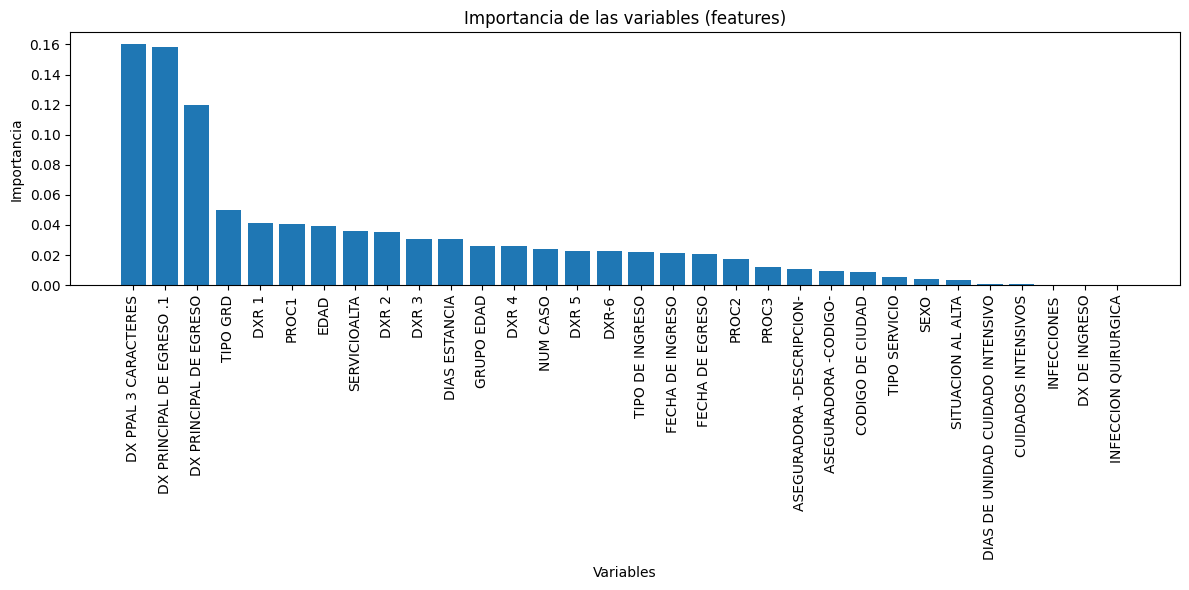

In [22]:
import matplotlib.pyplot as plt
import numpy as np

importancias = best_model.feature_importances_
indices = np.argsort(importancias)[::-1] 

plt.figure(figsize=(12,6))
plt.title("Importancia de las variables (features)")
plt.bar(range(len(importancias)), importancias[indices], align="center")
plt.xticks(range(len(importancias)), X_RF.columns[indices], rotation=90)
plt.ylabel("Importancia")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

### Almacenamiento del modelo

In [23]:
import joblib


# Guardar el modelo
joblib.dump(best_model, 'modelo_grd.pkl')

# Guardar las columnas usadas (lista)
joblib.dump(X_RF.columns.tolist(), 'columnas_modelo.pkl')


['columnas_modelo.pkl']

In [24]:
import os

BASE_DIR = os.getcwd()    
SCALER_PATH = os.path.join(BASE_DIR, 'scaler_modelo.pkl')
COLUMNAS_PATH = os.path.join(BASE_DIR, 'columnas_modelo.pkl')

scaler2 = joblib.load(SCALER_PATH)
columnas = joblib.load(COLUMNAS_PATH)


print(f"Número columnas escaladas: {scaler2.n_features_in_}")
print(f"Columnas escaladas: {scaler2.feature_names_in_}")
print(f"Número columnas : {len(columnas)}")
print(f"Columnas modelo: {columnas}")

Número columnas escaladas: 32
Columnas escaladas: ['NUM CASO' 'ASEGURADORA -CODIGO-' 'ASEGURADORA -DESCRIPCION-' 'EDAD'
 'GRUPO EDAD' 'SEXO' 'CODIGO DE CIUDAD' 'FECHA DE INGRESO'
 'TIPO DE INGRESO' 'FECHA DE EGRESO' 'DIAS ESTANCIA' 'SERVICIOALTA'
 'CUIDADOS INTENSIVOS' 'DIAS DE UNIDAD CUIDADO INTENSIVO' 'DX DE INGRESO'
 'DX PRINCIPAL DE EGRESO' 'DX PRINCIPAL DE EGRESO .1'
 'DX PPAL 3 CARACTERES' 'DXR 1' 'DXR 2' 'DXR 3' 'DXR 4' 'DXR 5' 'DXR-6'
 'SITUACION AL ALTA' 'PROC1' 'PROC2' 'PROC3' 'TIPO SERVICIO' 'INFECCIONES'
 'INFECCION QUIRURGICA' 'TIPO GRD']
Número columnas : 32
Columnas modelo: ['NUM CASO', 'ASEGURADORA -CODIGO-', 'ASEGURADORA -DESCRIPCION-', 'EDAD', 'GRUPO EDAD', 'SEXO', 'CODIGO DE CIUDAD', 'FECHA DE INGRESO', 'TIPO DE INGRESO', 'FECHA DE EGRESO', 'DIAS ESTANCIA', 'SERVICIOALTA', 'CUIDADOS INTENSIVOS', 'DIAS DE UNIDAD CUIDADO INTENSIVO', 'DX DE INGRESO', 'DX PRINCIPAL DE EGRESO', 'DX PRINCIPAL DE EGRESO .1', 'DX PPAL 3 CARACTERES', 'DXR 1', 'DXR 2', 'DXR 3', 'DXR 4', 'DXR 5